# NEOFC: Prepare reference data

In [1]:
from pathlib import Path 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from nilearn.plotting import plot_stat_map, plot_surf_stat_map
from nilearn.image import resample_img

from neuromaps.datasets import fetch_fslr
from neuromaps.images import load_nifti, load_gifti

from nispace import datasets
from nispace.nulls import get_distance_matrix
from nispace.stats.autocorr import morans_i
from nispace.stats.misc import residuals_nan
from nispace.stats.coloc import pearson, rank1d
from nispace.utils.utils import vect_to_vol_arr

from mapconn.percentiles import values_to_percentiles

from utils import REF_GROUPS, PARCS_CX, get_ref_data, get_dist_mat, REF_NAMES_PET, REF_GROUPS_PET
from nulls import spin_nulls, moran_nulls

# working directory
wd = Path.cwd() 
print(wd)

/Users/llotter/projects/mapfc


## NiSpace version

In [2]:
from nispace import __commit__
__commit__

'0.0.1-beta.4+7.ga71d1f2'

## Get parcellations

INFO | 13/04/26 17:51:11 | nispace: Loading MNI152NLin6Asym 'T1w' template in '1mm' resolution.
Schaefer100
INFO | 13/04/26 17:51:11 | nispace: Loading cortex parcellation 'Schaefer100' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:11 | nispace: Loading cortex parcellation 'Schaefer100' in 'fsLR' space.


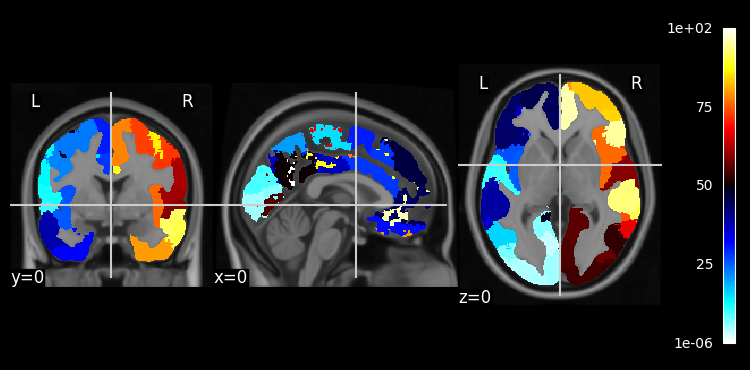

Schaefer200
INFO | 13/04/26 17:51:12 | nispace: Loading cortex parcellation 'Schaefer200' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:12 | nispace: Loading cortex parcellation 'Schaefer200' in 'fsLR' space.


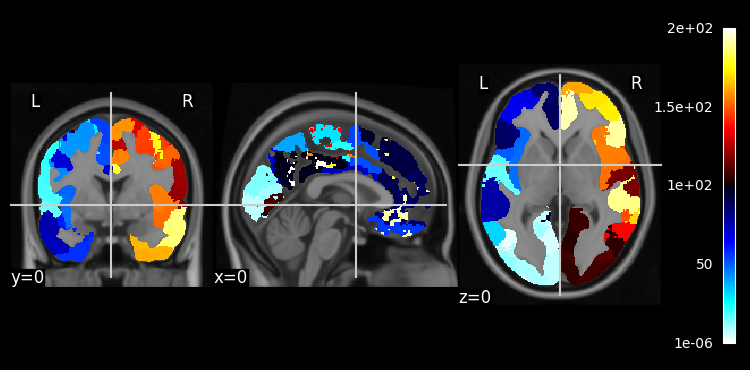

Schaefer400
INFO | 13/04/26 17:51:14 | nispace: Loading cortex parcellation 'Schaefer400' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:14 | nispace: Loading cortex parcellation 'Schaefer400' in 'fsLR' space.


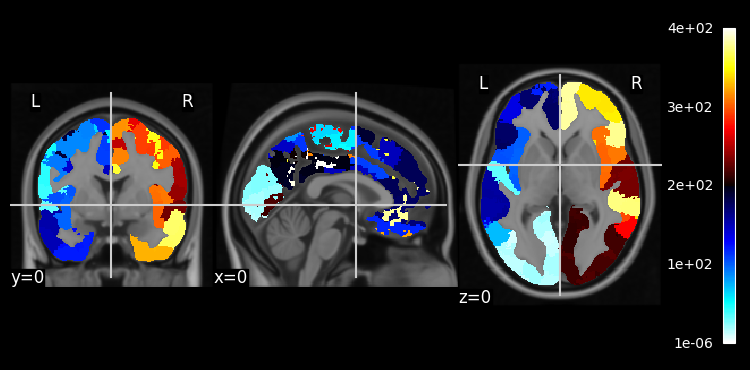

Subcortical
INFO | 13/04/26 17:51:15 | nispace: Loading subcortex parcellation 'Aseg' in 'MNI152NLin6Asym' space.


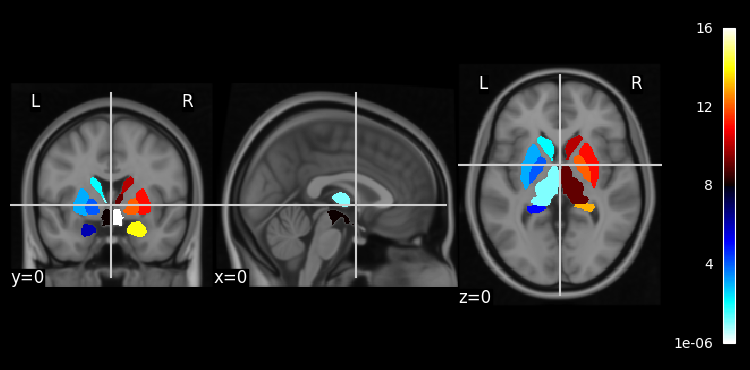

Schaefer100Subcortical
INFO | 13/04/26 17:51:17 | nispace: Loading cortex parcellation 'Schaefer100' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:17 | nispace: Loading subcortex parcellation 'Aseg' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:17 | nispace: Merging to cortex-subcortex parcellation 'Schaefer100Aseg'.


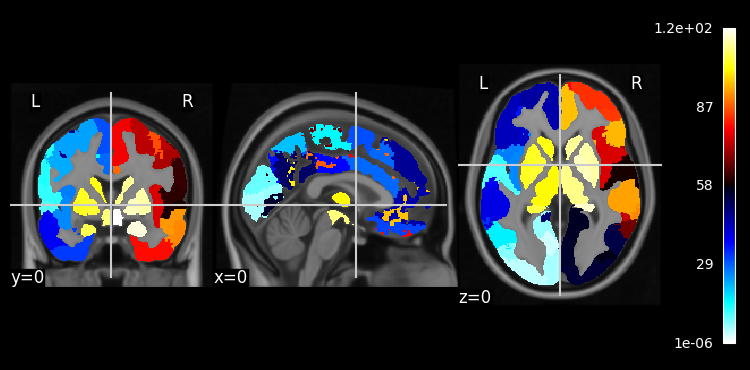

Schaefer200Subcortical
INFO | 13/04/26 17:51:18 | nispace: Loading cortex parcellation 'Schaefer200' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:18 | nispace: Loading subcortex parcellation 'Aseg' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:18 | nispace: Merging to cortex-subcortex parcellation 'Schaefer200Aseg'.


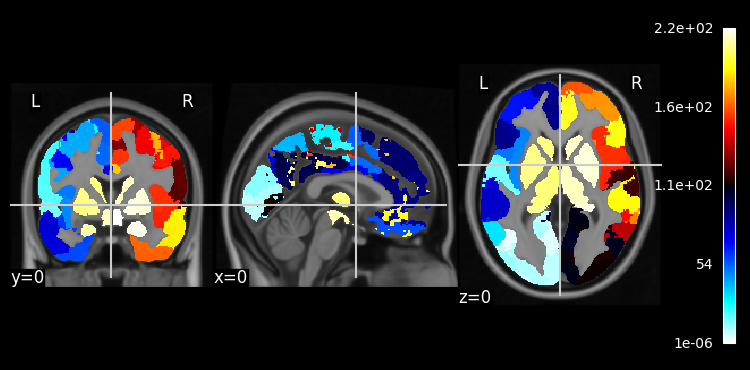

Schaefer400Subcortical
INFO | 13/04/26 17:51:20 | nispace: Loading cortex parcellation 'Schaefer400' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:20 | nispace: Loading subcortex parcellation 'Aseg' in 'MNI152NLin6Asym' space.
INFO | 13/04/26 17:51:20 | nispace: Merging to cortex-subcortex parcellation 'Schaefer400Aseg'.


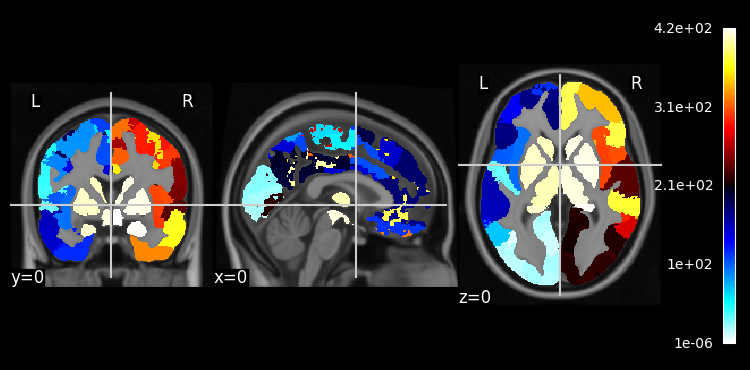

Schaefer100
mni152: <class 'nibabel.nifti1.Nifti1Image'>, indices: [0. 1. 2.] - [ 98.  99. 100.]
labels: <class 'pandas.core.series.Series'>, indices: Index([1, 2, 3], dtype='int64') - Index([98, 99, 100], dtype='int64') , values: ['hemi-L_div-Vis_lab-1' 'hemi-L_div-Vis_lab-2' 'hemi-L_div-Vis_lab-3'] - ['hemi-R_div-Default_lab-PFCm+3' 'hemi-R_div-Default_lab-PCC+1'
 'hemi-R_div-Default_lab-PCC+2']
fslr: <class 'tuple'>, indices-L: [0 1 2] - [48 49 50] , indices-R: [ 0 51 52] - [ 98  99 100]
Schaefer200
mni152: <class 'nibabel.nifti1.Nifti1Image'>, indices: [0. 1. 2.] - [198. 199. 200.]
labels: <class 'pandas.core.series.Series'>, indices: Index([1, 2, 3], dtype='int64') - Index([198, 199, 200], dtype='int64') , values: ['hemi-L_div-Vis_lab-1' 'hemi-L_div-Vis_lab-2' 'hemi-L_div-Vis_lab-3'] - ['hemi-R_div-Default_lab-PCC+1' 'hemi-R_div-Default_lab-PCC+2'
 'hemi-R_div-Default_lab-PCC+3']
fslr: <class 'tuple'>, indices-L: [0 1 2] - [ 98  99 100] , indices-R: [  0 101 102] - [198 199 200]
S

In [38]:
parcellations = {}

# MNI152NLin6Asym template
tpl = datasets.fetch_template("MNI152NLin6Asym", "1mm", "T1w")

# We load most data and parcellations via NiSpace.
# Schaefer 100, 200, 400: MNI152NLin6Asym and fsLR

# --------------------------------------------------------------------------------------------------
# schaefer
for schaefer in [100, 200, 400]:
    parc_name = f"Schaefer{schaefer}"
    print(parc_name)
    parc_mni152, parc_labels = datasets.fetch_parcellation(parc_name, space="MNI152NLin6Asym")
    parc_fslr, _ = datasets.fetch_parcellation(parc_name, space="fsLR")
    parc_labels = pd.Series(parc_labels, name="label", index=list(range(1, len(parc_labels)+1)))
    parcellations[parc_name] = {
        "mni152": parc_mni152,
        "labels": parc_labels,
        "fslr": parc_fslr,
    }
    plot_stat_map(parcellations[parc_name]["mni152"], cut_coords=(0, 0, 0), bg_img=tpl)
    plt.show()

# --------------------------------------------------------------------------------------------------
# FreeSurfer subcortical parcellation
parc_name = "Subcortical"
print(parc_name)
parc_mni152, parc_labels = datasets.fetch_parcellation("Aseg", space="MNI152NLin6Asym")
parc_labels = pd.Series(parc_labels, name="label", index=list(range(1, len(parc_labels)+1)))
parcellations[parc_name] = {
    "mni152": parc_mni152,
    "labels": parc_labels,
}
plot_stat_map(parcellations[parc_name]["mni152"], cut_coords=(0, 0, 0), bg_img=tpl)
plt.show()

# --------------------------------------------------------------------------------------------------
# schaefer + subcortical
for schaefer in [100, 200, 400]:
    parc_name = f"Schaefer{schaefer}Subcortical"
    print(parc_name)
    parc_mni152, parc_labels = datasets.fetch_parcellation(parc_name.replace("Subcortical", "Aseg"), space="MNI152NLin6Asym")
    parc_labels = pd.Series(parc_labels, name="label", index=list(range(1, len(parc_labels)+1)))
    parcellations[parc_name] = {
        "mni152": parc_mni152,
        "labels": parc_labels,
    }
    plot_stat_map(parcellations[parc_name]["mni152"], cut_coords=(0, 0, 0), bg_img=tpl)
    plt.show()
    
## CHECKS -------------------------------------------------------------------------------------------------------------------
for parc_name in parcellations:
    print(parc_name)
    for k in parcellations[parc_name].keys():
        if k == "mni152":
            print(f"{k}: {type(parcellations[parc_name][k])}, "
                  f"indices: {np.unique(parcellations[parc_name][k].get_fdata())[:3]} - {np.unique(parcellations[parc_name][k].get_fdata())[-3:]}")
        elif k == "fslr":
            print(f"{k}: {type(parcellations[parc_name][k])}, "
                  f"indices-L: {np.unique(parcellations[parc_name][k][0].agg_data())[:3]} - {np.unique(parcellations[parc_name][k][0].agg_data())[-3:]} , "
                  f"indices-R: {np.unique(parcellations[parc_name][k][1].agg_data())[:3]} - {np.unique(parcellations[parc_name][k][1].agg_data())[-3:]}")
        elif k == "labels":
            print(f"{k}: {type(parcellations[parc_name][k])}, "
                  f"indices: {parcellations[parc_name][k].index[:3]} - {parcellations[parc_name][k].index[-3:]} , "
                  f"values: {parcellations[parc_name][k].values[:3]} - {parcellations[parc_name][k].values[-3:]}")
    
    
    
## SAVE ---------------------------------------------------------------------------------------------------------------------
for parc_name in parcellations:
    for k in parcellations[parc_name].keys():
        if k == "mni152":
            parcellations[parc_name][k].to_filename(wd / "parcellation" / f"parc-{parc_name}.label.nii.gz")
        elif k == "fslr":
            for i, hemi in enumerate(["L", "R"]):
                parcellations[parc_name][k][i].to_filename(wd / "parcellation" / f"parc-{parc_name}_hemi-{hemi}.label.gii")
        elif k == "labels":
            parcellations[parc_name][k].to_csv(wd / "parcellation" / f"parc-{parc_name}.label.csv")


In [4]:
for parc_name in ["Subcortical", "Schaefer100", "Schaefer200", "Schaefer400"]:
    img = load_nifti(parcellations[parc_name]["mni152"])
    img = resample_img(img, target_affine=np.eye(3), interpolation="nearest")
    idc, counts = np.unique(img.get_fdata(), return_counts=True)
    counts = counts[1:]
    print(f"{parc_name}: n = {len(counts)}, mean = {counts.mean():.02f}, std = {counts.std():.02f}")

Subcortical: n = 16, mean = 4802.38, std = 2678.29
Schaefer100: n = 100, mean = 10556.85, std = 4441.73
Schaefer200: n = 200, mean = 5278.43, std = 2104.77
Schaefer400: n = 400, mean = 2639.21, std = 1105.29


### Get distance matrices

In [5]:
overwrite = False

for parc_name in parcellations.keys():

    # filepath
    fp = wd / "parcellation" / f"parc-{parc_name}.distmat.csv"
    if fp.exists() and not overwrite:
        print(f"{fp} already exists, skipping...")
        continue
    
    # get matrix
    dist_mat = get_distance_matrix(
        parc=parcellations[parc_name]["mni152"],
        parc_space="mni152",
        parc_resample=2,
        n_proc=-1
    )

    # save
    pd.DataFrame(
        dist_mat,
        index=parcellations[parc_name]["labels"],
        columns=parcellations[parc_name]["labels"]
    ) \
    .to_csv(fp)


/Users/llotter/projects/mapfc/parcellation/parc-Schaefer100.distmat.csv already exists, skipping...
/Users/llotter/projects/mapfc/parcellation/parc-Schaefer200.distmat.csv already exists, skipping...
/Users/llotter/projects/mapfc/parcellation/parc-Schaefer400.distmat.csv already exists, skipping...
/Users/llotter/projects/mapfc/parcellation/parc-Subcortical.distmat.csv already exists, skipping...
/Users/llotter/projects/mapfc/parcellation/parc-Schaefer100Subcortical.distmat.csv already exists, skipping...
/Users/llotter/projects/mapfc/parcellation/parc-Schaefer200Subcortical.distmat.csv already exists, skipping...
/Users/llotter/projects/mapfc/parcellation/parc-Schaefer400Subcortical.distmat.csv already exists, skipping...


## Get reference data

In [6]:

# nuclear imaging data from NiSpace. The following will load all the maps, resampled to MNI152NLin6Asym
# we do it only to get the map names, we will load pre-parcellated data below
maps_pet = [
    'target-5HT1a_tracer-cumi101_n-8_dx-hc_pub-beliveau2017',
    'target-5HT1b_tracer-az10419369_n-36_dx-hc_pub-beliveau2017',
    'target-5HT2a_tracer-cimbi36_n-29_dx-hc_pub-beliveau2017',
    'target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beliveau2017',
    'target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018',
    'target-5HTT_tracer-dasb_n-100_dx-hc_pub-beliveau2017',
    'target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016',
    'target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015',
    'target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023',
    'target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller2017',
    'target-D23_tracer-flb457_n-55_dx-hc_pub-sandiego2015',
    'target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018',
    'target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-garciagomez2018',
    'target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022',
    'target-GABAa_tracer-flumazenil_n-16_dx-hc_pub-norgaard2021',
    'target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016',
    'target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018',
    'target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020',
    'target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019',
    'target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020',
    'target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017',
    'target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021',
    'target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016',
    'target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017',
    'target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020'
]
print(f"{len(maps_pet)} nuclear imaging maps")
display(maps_pet)

# RSN data from NiSpace
# RSN data in fsLR space was downloaded from the MIDB website to this project's data_source folder
maps_rsn = {
    'nw-Vis': "Visual",
    'nw-Aud': "Auditory",
    'nw-SMl': "Lateral Somatomotor",
    'nw-SMd': "Dorsal Somatomotor",
    'nw-VAN': "Ventral Attention",
    'nw-DAN': "Dorsal Attention", 
    'nw-CO': "Cingulo-Opercular", 
    'nw-FP': "Frontoparietal", 
    'nw-PMN': "Medial Parietal",
    'nw-PON': "Occipital Parietal",
    'nw-Sal': "Salience",
    'nw-DMN': "Default Mode",
}
print(f"{len(maps_rsn)} RSN maps")
display(maps_rsn)

# standard maps of t1/t2 ratio and Sensory-Association-Axis for control analysis
maps_sa = ["t1t2", "saaxis"]
display(maps_sa)

# tissue probability maps
maps_tpm = ["tissue-gm", "tissue-csf", "tissue-veins", "tissue-arteries"]
display(maps_tpm)

# histoarchitecture
maps_bigbrain = ["histogradient1", "histogradient2", "microgradient1", "microgradient2", "funcgradient1", "funcgradient2"]
display(maps_bigbrain)

25 nuclear imaging maps


['target-5HT1a_tracer-cumi101_n-8_dx-hc_pub-beliveau2017',
 'target-5HT1b_tracer-az10419369_n-36_dx-hc_pub-beliveau2017',
 'target-5HT2a_tracer-cimbi36_n-29_dx-hc_pub-beliveau2017',
 'target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beliveau2017',
 'target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018',
 'target-5HTT_tracer-dasb_n-100_dx-hc_pub-beliveau2017',
 'target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016',
 'target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015',
 'target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023',
 'target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller2017',
 'target-D23_tracer-flb457_n-55_dx-hc_pub-sandiego2015',
 'target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018',
 'target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-garciagomez2018',
 'target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022',
 'target-GABAa_tracer-flumazenil_n-16_dx-hc_pub-norgaard2021',
 'target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016',
 'target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vi

12 RSN maps


{'nw-Vis': 'Visual',
 'nw-Aud': 'Auditory',
 'nw-SMl': 'Lateral Somatomotor',
 'nw-SMd': 'Dorsal Somatomotor',
 'nw-VAN': 'Ventral Attention',
 'nw-DAN': 'Dorsal Attention',
 'nw-CO': 'Cingulo-Opercular',
 'nw-FP': 'Frontoparietal',
 'nw-PMN': 'Medial Parietal',
 'nw-PON': 'Occipital Parietal',
 'nw-Sal': 'Salience',
 'nw-DMN': 'Default Mode'}

['t1t2', 'saaxis']

['tissue-gm', 'tissue-csf', 'tissue-veins', 'tissue-arteries']

['histogradient1',
 'histogradient2',
 'microgradient1',
 'microgradient2',
 'funcgradient1',
 'funcgradient2']

### Load PET metadata via NiSpace

In [7]:
# file is shipped internally in NiSpace"
fp = Path.home() / "nispace-data" / "reference" / "pet" / "metadata.csv"
pet_metadata = pd.read_csv(fp, index_col=0)

# restrict to selected atlases and interesting variables, add group variable
pet_metadata = pet_metadata.loc[maps_pet][["target", "tracer", "metric", 
                                           "sample_size", "n_female", "age_mean", "age_sd", "age_min", "age_max",
                                           "publication", "doi", "license"]]
pet_metadata.publication = pet_metadata.publication.str.title()
for group, m in REF_GROUPS_PET.items():
    pet_metadata.loc[pet_metadata.target.isin(m), "group"] = group
pet_metadata = pet_metadata.set_index(["group", "target"])

# sort like in the paper
pet_metadata = pet_metadata.loc[(slice(None), REF_NAMES_PET), :]

# save 
pet_metadata.to_csv(wd / "data_deriv" / "reference" / "pet" / "metadata.csv")

# show
pet_metadata

tracer  metric  sample_size  \
group                         target                                          
General & Metabolic           CMRglu          [18F]FDG  CMRglu           20   
                              SV2A          [11C]UCB-J    BPnd           76   
                              HDAC    [11C]Martinostat    SUVR            8   
                              VMAT2          [11C]DTBZ    BPnd           76   
Glutamate & GABA              mGluR5       [11C]ABP688    BPnd           73   
                              NMDA         [18F]GE-179      Vt           29   
                              GABAa    [11C]Flumazenil    Bmax           16   
                              GABAa5    [11C]Ro15-4513    BPnd           10   
Noradrenaline & Acetylcholine NET             [11C]MRB    BPnd           10   
                              A4B2      [18F]Flubatine      Vt           30   
                              M1       [11C]LSN3172176    BPnd           24   
                              VAChT         [18F]FEOBV    SUVR           18   
Dopamine                      FDOPA          [18F]DOPA     NaN           12   
                              D1         [11C]SCH23390    BPnd           13   
                              D23         [11C]FLB-457    BPnd           55   
                              DAT        [123I]-FP-CIT    SUVR          174   
Serotonin                     5HT1a      [11C]CUMI-101    Bmax            8   
                              5HT1b    [11C]AZ10419369    Bmax           36   
                              5HT2a      [11C]Cimbi-36    Bmax           29   
                              5HT4       [11C]SB207145    Bmax           59   
                              5HT6      [11C]GSK215083    BPnd           30   
                              5HTT           [11C]DASB    Bmax          100   
Opioids & Endocannabinoids    MOR     [11C]Carfentanil    BPnd          204   
                              KOR       [11C]LY2795050      Vt           28   
                              CB1            [11C]OMAR      Vt           77   

                                      n_female  age_mean  age_sd  age_min  \
group                         target                                        
General & Metabolic           CMRglu      10.0     34.45    9.96    22.00   
                              SV2A         NaN     48.90   18.40      NaN   
                              HDAC         4.0     28.60    7.60    18.00   
                              VMAT2       37.0     23.40    3.63    18.11   
Glutamate & GABA              mGluR5      48.0     19.90    3.04      NaN   
                              NMDA         8.0     40.90   12.70      NaN   
                              GABAa        9.0     26.60    8.00    19.00   
                              GABAa5       4.0     25.40    3.20    22.00   
Noradrenaline & Acetylcholine NET          4.0     33.30   10.00    21.00   
                              A4B2        10.0     33.50   10.71      NaN   
                              M1          11.0     40.45   11.71      NaN   
                              VAChT       13.0     66.80    6.80      NaN   
Dopamine                      FDOPA        NaN       NaN     NaN      NaN   
                              D1           6.0     33.00   13.00      NaN   
                              D23         29.0     32.45    9.69      NaN   
                              DAT         65.0     61.00   11.00      NaN   
Serotonin                     5HT1a        5.0     28.40    8.80      NaN   
                              5HT1b       12.0     27.80    6.90      NaN   
                              5HT2a       14.0     22.60    2.70      NaN   
                              5HT4        18.0     25.90    5.30      NaN   
                              5HT6         0.0     36.60    9.04      NaN   
                              5HTT        71.0     25.10    5.80      NaN   
Opioids & Endocannabinoids    MOR         72.0     32.30   10.80  

### Load and reorder PET data from NiSpace

In [8]:
for parc in parcellations.keys():
    
    # get data
    parc_df = datasets.fetch_reference(
        "pet",
        maps=maps_pet,
        parcellation=parc.replace("Subcortical", "Aseg"),
        verbose=False,
        print_references=False,
        standardize_parcellated=False,
    )
    if parc_df.shape[0] != len(maps_pet):
        raise ValueError(f"Parc {parc} has {parc_df.shape[0]} maps, expected {len(maps_pet)}")
               
    # relabel
    parc_df.index = [m.split("target-")[1].split("_")[0] for m in parc_df.index]
    
    # zscore
    parc_df_z = parc_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
    
    # save
    parc_df.to_csv(wd / "data_deriv" / "reference" / "pet" / f"reference_dset-pet_parc-{parc}.csv")
    parc_df_z.to_csv(wd / "data_deriv" / "reference" / "pet" / f"reference_dset-pet_parc-{parc}_z.csv")        

#### Calculate spatial autocorrelation (Moran's I)

In [9]:
for parc in parcellations.keys():
    
    # get data
    parc_df = get_ref_data("pet", parcs=parc)
    dist_mat = get_dist_mat(parcs=parc)
    
    # calculate spatial autocorrelation
    sac_df = pd.DataFrame.from_dict(
        {
            m: morans_i(parc_df.loc[m].values, dist_mat.values)
            for m in parc_df.index
        },
        orient="index",
        columns=["morans_i"]
    )
    
    # save
    sac_df.to_csv(wd / "data_deriv" / "reference" / "pet" / f"reference_dset-pet_parc-{parc}_sac.csv")

Loading parcellated pet data, standardized=True, null=False
Loading parcellated pet data, standardized=True, null=False
Loading parcellated pet data, standardized=True, null=False
Loading parcellated pet data, standardized=True, null=False
Loading parcellated pet data, standardized=True, null=False
Loading parcellated pet data, standardized=True, null=False
Loading parcellated pet data, standardized=True, null=False


Load data from Dworetsky et al. RSN probability maps

In [ ]:
for parc in PARCS_CX:
    
    # get data
    parc_df = datasets.fetch_reference(
        "rsn",
        maps=list(maps_rsn.keys()),
        parcellation=parc.replace("Subcortical", "Aseg"),
        verbose=False,
        print_references=False,
        standardize_parcellated=False,
    )
    if parc_df.shape[0] != len(maps_rsn):
        raise ValueError(f"Parc {parc} has {parc_df.shape[0]} maps, expected {len(maps_rsn)}")
    
    # new labels
    parc_df.index = parc_df.index.map(maps_rsn)
    
    # zscore
    parc_df_z = parc_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
    
    # save
    parc_df.to_csv(wd / "data_deriv" / "reference" / "rsn" / f"reference_dset-rsn_parc-{parc}.csv")
    parc_df_z.to_csv(wd / "data_deriv" / "reference" / "rsn" / f"reference_dset-rsn_parc-{parc}_z.csv")        

### Load covariate data from NiSpace

In [11]:
for parc in PARCS_CX:
    print(parc)
    
    tmp = []

    for dset, maps in [("cortexfeatures", maps_sa), ("tpm", maps_tpm), ("bigbrain", maps_bigbrain)]:
        print(f"Processing {dset} data")
            
        # get data
        parc_df = datasets.fetch_reference(
            dset,
            maps=maps,
            parcellation=parc.replace("Subcortical", "Aseg"),
            verbose=False,
            print_references=False,
            standardize_parcellated=False,
        )
        
        if parc_df.shape[0] != len(maps):
            raise ValueError(f"Parc {parc} has {parc_df.shape[0]} maps, expected {len(maps)}")
                
        # relabel
        parc_df.index = [
            m.split("feature-" if dset != "tpm" else "tissue-")[1].split("_")[0] 
            for m in parc_df.index
        ]
        
        # add to tmp
        tmp.append(parc_df)
        
    # concatenate
    parc_df = pd.concat(tmp, axis=0)
    
    # zscore
    parc_df_z = parc_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
    
    # add NET map
    parc_df.loc["NET"] = get_ref_data("pet", parcs=parc, standardized=False).loc["NET"]
    parc_df_z.loc["NET"] = get_ref_data("pet", parcs=parc, standardized=True).loc["NET"]
    
    # add residuals from NET ~ covariate_map
    for cov in parc_df.index[:-1]:
        parc_df.loc[f"NET-{cov}"] = residuals_nan(y=parc_df.loc["NET"].values, x=parc_df.loc[cov].values)
        parc_df_z.loc[f"NET-{cov}"] = residuals_nan(y=parc_df_z.loc["NET"].values, x=parc_df_z.loc[cov].values)
        
    # save
    save_dir = wd / "data_deriv" / "reference" / "cov"
    save_dir.mkdir(parents=True, exist_ok=True)
    parc_df.to_csv(save_dir / f"reference_dset-cov_parc-{parc}.csv")
    parc_df_z.to_csv(save_dir / f"reference_dset-cov_parc-{parc}_z.csv")

Schaefer100
Processing cortexfeatures data
Processing tpm data
Processing bigbrain data
Loading parcellated pet data, standardized=False, null=False
Loading parcellated pet data, standardized=True, null=False
Schaefer200
Processing cortexfeatures data
Processing tpm data
Processing bigbrain data
Loading parcellated pet data, standardized=False, null=False
Loading parcellated pet data, standardized=True, null=False
Schaefer400
Processing cortexfeatures data
Processing tpm data
Processing bigbrain data
Loading parcellated pet data, standardized=False, null=False
Loading parcellated pet data, standardized=True, null=False


## Calculate null maps

In [13]:
import gzip
import pickle

n_nulls = 1000

# iterate reference datasets
for fp_dset in (wd / "data_deriv" / "reference").iterdir():
    if not fp_dset.is_dir():
        continue
    dset = fp_dset.name
    print(f"{dset}: {fp_dset}")
    
    # iterate parcellations in dir
    for parc in parcellations:
        
        # skip if parcellation not available
        if len(list(fp_dset.glob(f"*parc-{parc}_z.csv"))) == 0:
            print(f"Skipping {parc}")
            continue    
        print(parc)

        # load observed data
        data_obs = pd.read_csv(fp_dset / f"reference_dset-{dset}_parc-{parc}_z.csv", index_col=0)
        
        # list to store null data
        data_null = {}
        
        # cortex: spins
        if parc != "Subcortical":
            
            # parcellation
            parc_cx = parc.replace("Subcortical", "")
            parc_surf = parcellations[parc_cx]["fslr"]
            parc_cx_labels = parcellations[parc_cx]["labels"]
            
            # data
            data_cx = data_obs[parc_cx_labels]
            
            # generate spin nulls
            null_maps = spin_nulls(
                data=data_cx,
                parc=parc_surf,
                n_nulls=n_nulls,
                seed=42,
            )
            data_null["cortex"] = null_maps

        # subcortex: moran
        if "Subcortical" in parc:
            
            # parcellation
            parc_sc = parcellations["Subcortical"]["mni152"]
            parc_sc_labels = parcellations["Subcortical"]["labels"]
            
            # data
            data_sc = data_obs[parc_sc_labels]
            
            # distance matrix
            distmat = get_dist_mat("Subcortical")
            
            # generate moran nulls
            null_maps = moran_nulls(
                data=data_sc,
                dist_mat=distmat,
                n_nulls=n_nulls,
                seed=42
            )
            data_null["subcortex"] = null_maps
            
        # combine nulls
        if len(data_null) == 1:
            k = list(data_null.keys())[0]
            data_null = data_null[k]
        else:
            data_null = {
                name: np.hstack([data_null["cortex"][name], data_null["subcortex"][name]])
                for name in data_obs.index
            }
        # check
        assert len(data_null) == data_obs.shape[0], f"Number of maps in null data ({len(data_null)}) does not match observed data ({data_obs.shape[0]})"
        for name in data_obs.index:
            assert data_null[name].shape == (n_nulls, data_obs.shape[1]), f"Null maps for {name} have shape {data_null[name].shape}, expected {(n_nulls, data_obs.shape[1])}"
        
        # save
        fp_null = fp_dset / f"reference_dset-{dset}_parc-{parc}_nulls.pkl.gz"        
        with gzip.open(fp_null, "wb") as f:
            pickle.dump(data_null, f)


rsn: /Users/llotter/projects/mapfc/data_deriv/reference/rsn
Schaefer100


100%|██████████| 12/12 [00:00<00:00, 54.04it/s]


Schaefer200


100%|██████████| 12/12 [00:00<00:00, 16080.40it/s]


Schaefer400


...

Schaefer200


100%|██████████| 25/25 [00:01<00:00, 21.94it/s]


Schaefer400


100%|██████████| 25/25 [00:02<00:00, 11.73it/s]


Skipping Subcortical
Skipping Schaefer100Subcortical
Skipping Schaefer200Subcortical
Skipping Schaefer400Subcortical


In [22]:
n_nulls = 1000

def corr_sc(data_1d, nulls, idc_lh, idc_rh):
    def corr(lh, rh):
        isnan = np.isnan(lh) | np.isnan(rh)
        return pearson(rank1d(lh[~isnan]), rank1d(rh[~isnan]))
    rho_obs = corr(data_1d[idc_lh], data_1d[idc_rh])
    rho_null = np.array([corr(nulls[i][idc_lh], nulls[i][idc_rh]) for i in range(n_nulls)])
    return rho_obs, rho_null

def corr_cx(data_1d, nulls, idc_lh, idc_rh, parc=parc_surf):
    parc_lh_arr = parc[0].agg_data()
    parc_rh_arr = parc[1].agg_data()
    parc_lh_idc = np.trim_zeros(np.unique(parc_lh_arr))
    parc_rh_idc = np.trim_zeros(np.unique(parc_rh_arr))
    assert len(idc_lh) == len(parc_lh_idc) and len(idc_rh) == len(parc_rh_idc), "Mismatch between idc and parc indices"
    def corr(lh, rh):
        lh_surf = vect_to_vol_arr(lh, parc_lh_arr, parc_lh_idc, bg_value=0)
        rh_surf = vect_to_vol_arr(rh, parc_rh_arr, parc_rh_idc, bg_value=0)
        isnan = np.isnan(lh_surf) | np.isnan(rh_surf)
        return pearson(lh_surf[~isnan], rh_surf[~isnan])
    rho_obs = corr(data_1d[idc_lh], data_1d[idc_rh])
    rho_null = np.array([corr(nulls[i][idc_lh], nulls[i][idc_rh]) for i in range(n_nulls)])
    return rho_obs, rho_null

# iterate reference datasets
for fp_dset in (wd / "data_deriv" / "reference").iterdir():
    if not fp_dset.is_dir():
        continue
    dset = fp_dset.name
    print(f"{dset}: {fp_dset}")
    
    # iterate parcellations in dir
    for parc in parcellations:
        
        if len(list(fp_dset.glob(f"*parc-{parc}_z.csv"))) == 0:
            print(f"Skipping {parc}")
            continue    
        print(parc)
        
        # load observed data
        data_obs = pd.read_csv(fp_dset / f"reference_dset-{dset}_parc-{parc}_z.csv", index_col=0)
        
        # load null data
        fp_null = fp_dset / f"reference_dset-{dset}_parc-{parc}_nulls.pkl.gz"
        with gzip.open(fp_null, "rb") as f:
            data_null = pickle.load(f)
            
        # load distance matrix
        distmat = get_dist_mat(parc)
            
        # iterate maps
        for m in data_obs.index:
            
            # calculate spatial autocorrelation for observed and null data
            sac_obs = morans_i(data_obs.loc[m], distmat, normalize=True)
            sac_null = np.array([morans_i(data_null[m][i], distmat, normalize=True) for i in range(n_nulls)])
            
            # calculate interhemispheric correlation for subcortex
            if "Subcortical" in parc:
                labels_sc = parcellations["Subcortical"]["labels"]
                idc = np.where(data_obs.columns.isin(labels_sc))[0]
                idc_lh = idc[:len(idc)//2]
                idc_rh = idc[len(idc)//2:]
                rho_obs_sc, rho_null_sc = corr_sc(data_obs.loc[m].values, data_null[m], idc_lh=idc_lh, idc_rh=idc_rh)
            
            # calculate interhemispheric correlation for cortex (if applicable)
            if parc != "Subcortical":
                parc_cx = parc.replace("Subcortical", "")
                labels_cx = parcellations[parc_cx]["labels"]
                idc = np.where(data_obs.columns.isin(labels_cx))[0]
                idc_lh = idc[:len(idc)//2]
                idc_rh = idc[len(idc)//2:]
                rho_obs_cx, rho_null_cx = corr_cx(
                    data_obs.loc[m].values, data_null[m], parc=parcellations[parc_cx]["fslr"],
                    idc_lh=idc_lh, idc_rh=idc_rh)
                
            # plot
            fig, axes = plt.subplots(1, 3, figsize=(8,2.3))
            fig.suptitle(f"{dset}: {m} - {parc}", y=1.2, weight="bold")
            
            # autocorrelation: 
            axes[0].hist(sac_null, bins=20, density=True)
            axes[0].axvline(sac_obs, color="red", linestyle="--")
            axes[0].set_title("Spatial autocorrelation\n(normalized Moran's I)")
            
            # symmetry:
            if parc != "Subcortical":
                axes[1].hist(rho_null_cx, bins=20, density=True)
                axes[1].axvline(rho_obs_cx, color="red", linestyle="--")
                axes[1].set_xlim(0,1)
                axes[1].set_title("Cortical symmetry\n(rho across vertices)")
            else:
                axes[1].axis("off")
            if "Subcortical" in parc:
                axes[2].hist(rho_null_sc, bins=20, density=True)
                axes[2].axvline(rho_obs_sc, color="red", linestyle="--")
                axes[2].set_xlim(0,1)
                axes[2].set_title("Subcortical symmetry\n(rho across parcels)")
            else:
                axes[2].axis("off")
            plt.savefig(wd / "plots" / "null_maps" / f"reference_dset-{dset}_parc-{parc}_map-{m}.svg", bbox_inches="tight")
            plt.close()

rsn: /Users/llotter/projects/mapfc/data_deriv/reference/rsn
Schaefer100
Schaefer200
Schaefer400
Skipping Subcortical
Skipping Schaefer100Subcortical
Skipping Schaefer200Subcortical
Skipping Schaefer400Subcortical
pet: /Users/llotter/projects/mapfc/data_deriv/reference/pet
Schaefer100
Schaefer200
Schaefer400
Subcortical
Schaefer100Subcortical
Schaefer200Subcortical
Schaefer400Subcortical
cov: /Users/llotter/projects/mapfc/data_deriv/reference/cov
Schaefer100
Schaefer200
Schaefer400
Skipping Subcortical
Skipping Schaefer100Subcortical
Skipping Schaefer200Subcortical
Skipping Schaefer400Subcortical


## Plot reference data

In [11]:
from utils import PARCS_ALL
from utils import get_ref_data
from nispace.utils.utils import vect_to_vol_arr, parc_vect_to_vol
from nilearn.plotting import plot_surf_contours
from nilearn.plotting import plot_roi

def plot_parc_data(data, surf_map=None, bg_map=None, parc_map=None, ax=None, fig=None, 
                   zoom=1.5, cmap="viridis",
                   views=["left_lateral", "left_medial", "right_medial", "right_lateral"],
                   fslr_surf="inflated",
                   vmin=None, vmax=None,
                   plot_contours=True):
    
    if ax is None:
        fig, ax = plt.subplots(1, figsize=(len(views) * 2, 2))
    ax.set_axis_off()
    
    if surf_map is None or bg_map is None:
        fslr = fetch_fslr(density="32k")
        if surf_map is None:
            surf_map = (load_gifti(fslr[fslr_surf][0]), 
                        load_gifti(fslr[fslr_surf][1]))
        if bg_map is None:
            bg_map = (load_gifti(fslr["sulc"][0]), 
                      load_gifti(fslr["sulc"][1]))
            
    surf_dat = [surf.agg_data() for surf in surf_map]
    bg_dat = [bg.agg_data() for bg in bg_map]
    
    if parc_map:
        if parc_map in PARCS_ALL:
            parc_map = (load_gifti(wd / "parcellation" / f"parc-{parc_map}_hemi-L.label.gii"), 
                        load_gifti(wd / "parcellation" / f"parc-{parc_map}_hemi-R.label.gii"))
    else:
        raise ValueError("Provide parcellation map as Gifti file or string in "
                         "Schaefer{100|200|400}, Schaefer{100|200|400}Subcortical, Glasser")
    parc_dat = (parc_map[0].agg_data(), 
                parc_map[1].agg_data())
    parc_idc = (np.trim_zeros(np.unique(parc_dat[0])), 
                np.trim_zeros(np.unique(parc_dat[1])))
    data = (np.array(data)[:len(parc_idc[0])], 
            np.array(data)[len(parc_idc[0]):])
    if data[0].shape != parc_idc[0].shape or data[1].shape != parc_idc[1].shape:
        raise ValueError("Data shape does not match parcellation indices.", 
                         data[0].shape, data[1].shape, parc_idc[0].shape, parc_idc[1].shape)
    
    data_dat = (vect_to_vol_arr(data[0], parc_dat[0], parc_idc[0]), 
                vect_to_vol_arr(data[1], parc_dat[1], parc_idc[1]))
    try:
        medial_dat = (load_gifti(fslr["medial"].L).agg_data(), 
                      load_gifti(fslr["medial"].R).agg_data())
        data_dat = (np.where(medial_dat[0] == 0, np.nan, data_dat[0]),
                    np.where(medial_dat[1] == 0, np.nan, data_dat[1]))
    except:
        pass

    x_prop = 1 / len(views)
    for i, view in enumerate(views):
        hemi, perspective = view.split("_")
        ax_view = ax.inset_axes((x_prop * i, 0, x_prop, 1), projection="3d")
        
        p = plot_surf_stat_map(
            surf_dat[0 if hemi == "left" else 1],
            bg_map=bg_dat[0 if hemi == "left" else 1],
            stat_map=data_dat[0 if hemi == "left" else 1],
            hemi=hemi,
            view=perspective,
            axes=ax_view,
            figure=fig,
            bg_on_data=True,
            vmin=vmin,
            vmax=vmax,
            alpha=1,
            colorbar=False,
            cmap=cmap
        )
        if plot_contours:
            plot_surf_contours(
                surf_dat[0 if hemi == "left" else 1],
                #bg_map=bg_dat[0 if hemi == "left" else 1],
                roi_map=parc_dat[0 if hemi == "left" else 1],
                hemi=hemi,
                view=perspective,
                axes=ax_view,
                figure=fig,
                colors=["k"] * len(np.unique(parc_dat[0 if hemi == "left" else 1])),
            )
        ax_view.set_box_aspect(ax_view.get_box_aspect(), zoom=zoom)
        
    return p


# test
# parc_name = "Schaefer100"
# data = get_ref_data("rsn", parcs=parc_name, standardized=True, priority_only=True)

# plot_parc_data(
#     data=data.loc[("Visual")],
#     parc_map=parc_name
# )


In [12]:
import matplotlib
matplotlib.use('Agg')
overwrite = False

for dset in ["rsn", "pet", "sa", "tpm", "gradients"]:    
    for parc_name in PARCS_ALL:
        if dset in ["rsn", "sa", "gradients"] and "Subcortical" in parc_name:
            continue
        data = get_ref_data(dset, parcs=parc_name, standardized=True)
        
        for m in data.index:
            print(f"{dset} - {parc_name} - {m}")
            
            save_path = wd / "plots" / "reference" / f"reference-{m.replace(' ', '').replace('-', '')}_parc-{parc_name}.png"
            if save_path.exists() and not overwrite:
                print(f"Skipping {m} {parc_name}.")
                continue
            
            # convert to percentiles
            data_prc = values_to_percentiles(data.loc[m])
            # replace 0 with small value, only for plotting
            data_prc[data_prc==0] = 1e-3

            # plot settings
            plot_cx, plot_sc = False, False
            idc_cx, idc_sc = slice(None), slice(None)
            
            if parc_name in ["Schaefer100", "Schaefer200", "Schaefer400"]:
                plot_cx = True
                fig, ax_surf = plt.subplots(1, 1, figsize=(8, 2))
                
            elif "Subcortical" in parc_name:
                if m in REF_GROUPS["Resting-State Networks"]:
                    continue
                
                plot_cx, plot_sc = True, True
                idc_sc = np.arange(len(data.columns))[-16:]
                idc_cx = np.setdiff1d(np.arange(len(data.columns)), idc_sc)
                fig, ax = plt.subplots(1, 1, figsize=(10, 2))
                ax.set_axis_off()
                ax_surf = ax.inset_axes((0, 0, 1-1/5, 1))
                shrink = 0.03
                ax_sc = ax.inset_axes((1-1/5 + shrink, 0 + shrink, 1/5 - shrink*2, 1 - shrink))
                
            else:
                raise ValueError(f"Parcellation {parc_name} not recognized.")
                
            # plot surface
            if plot_cx:
                #print(parc_name, len(data_prc[idc_cx]), "data points")
                p = plot_parc_data(
                    data_prc[idc_cx], 
                    parc_map=parc_name.replace("Subcortical", ""),
                    ax=ax_surf,
                    fig=fig, 
                    zoom=1.5, 
                    vmin=0, 
                    vmax=100
                )
            
            # plot subcortical
            if plot_sc:
                
                parc_sc = load_nifti(wd / "parcellation" / f"parc-Subcortical.label.nii.gz")
                        
                p = plot_stat_map(
                    parc_vect_to_vol(data_prc[idc_sc], parc_sc),
                    bg_img=None,
                    cut_coords=[0],
                    display_mode="z",
                    cmap="viridis",
                    vmin=0,
                    vmax=100,
                    axes=ax_sc,
                    figure=fig,
                    colorbar=False,
                    annotate=False,
                    draw_cross=False,
                    alpha=0.9,
                )
                # p.add_contours(
                #     parc_sc,
                #     levels=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5],
                #     colors="k",
                #     linewidths=1
                # )
                # plot_roi(
                #     parc_sc,
                #     bg_img=None,
                #     cut_coords=[0],
                #     display_mode="z",
                #     axes=ax_sc,
                #     alpha=1,
                #     figure=fig,
                #     colorbar=False,
                #     annotate=False,
                #     draw_cross=False,
                #     linewidths=1,
                #     view_type="contours",
                #     resampling_interpolation="nearest",
                #     cmap=mpl.colors.ListedColormap(["k"])
                # )
                
            plt.savefig(save_path, bbox_inches="tight", dpi=400)
            plt.close(fig)
            del fig, p
            if "ax_surf" in locals():
                del ax_surf
            if "ax_sc" in locals():
                del ax_sc

Loading parcellated rsn data, standardized=True
rsn - Schaefer100 - Auditory
Skipping Auditory Schaefer100.
rsn - Schaefer100 - Cingulo-Opercular
Skipping Cingulo-Opercular Schaefer100.
rsn - Schaefer100 - Dorsal Attention
Skipping Dorsal Attention Schaefer100.
rsn - Schaefer100 - Default Mode
Skipping Default Mode Schaefer100.
rsn - Schaefer100 - Frontoparietal
Skipping Frontoparietal Schaefer100.
rsn - Schaefer100 - Medial Parietal
Skipping Medial Parietal Schaefer100.
rsn - Schaefer100 - Occipital Parietal
Skipping Occipital Parietal Schaefer100.
rsn - Schaefer100 - Dorsal Somatomotor
Skipping Dorsal Somatomotor Schaefer100.
rsn - Schaefer100 - Lateral Somatomotor
Skipping Lateral Somatomotor Schaefer100.
rsn - Schaefer100 - Salience
Skipping Salience Schaefer100.
rsn - Schaefer100 - Ventral Attention
Skipping Ventral Attention Schaefer100.
rsn - Schaefer100 - Visual
Skipping Visual Schaefer100.
Loading parcellated rsn data, standardized=True
rsn - Schaefer200 - Auditory
Skipping Au